<a href="https://colab.research.google.com/github/MAbbasiH/BDS/blob/main/Archetypal_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Archetypal Analysis

We will deliberately create a toy dataset suggesting four product types:

1. **Conventional firms** — low AI, low green
2. **AI specialists** — high AI, low green
3. **Green specialists** — low AI, high green
4. **Twin-transition firms** — high AI, high green

We then use **Archetypal Analysis (AA)** to see whether the data-driven extreme types recover these theoretically meaningful configurations.

AA represents observations as convex combinations of extreme points, rather than looking for average cluster centers. This approach also emphasizes choosing the number of archetypes using the RSS scree/elbow criterion and examining the alpha coefficients that locate observations in archetypal space.

## 1. Why Archetypal Analysis here?

Suppose we observe firms on two dimensions:

- x-axis = number of AI products
- y-axis = number of green / eco-friendly products

A conventional clustering method such as k-means asks:

> **Where are the centers of dense groups of firms?**

AA asks:

> **What are the extreme configurations that define the observed data space?**

For our theoretical framework, those extremes should approximately correspond to the four corners:

```text
                 Green products
                       ↑
                       |
       Green           |           Twin-transition
       specialists     |           firms
                       |
                       |
-----------------------+------------------------→ AI products
                       |
       Conventional    |           AI specialists
       firms           |
                       |
```

The important point is that **AA does not know these labels in advance**. We give it only the numerical data and ask it to discover the extreme configurations.

In [ ]:
# Install the exact package version used in this tutorial.
!pip -q install archetypes==0.12.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 12.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# NumPy: used for numerical operations and for generating the toy firm-level data.
import numpy as np

# pandas: used to create, manipulate, inspect, and summarize the firm-level dataset.
import pandas as pd

# Matplotlib: used to visualize the theoretical AI–green quadrants,
# archetypes, classifications, RSS scree plots, and other results.
import matplotlib.pyplot as plt

# StandardScaler: used to standardize AI and green product counts before
# applying distance-based methods such as K-means and Archetypal Analysis.
from sklearn.preprocessing import StandardScaler

# KMeans: used as a benchmark clustering method so we can compare
# conventional centroid-based clustering with Archetypal Analysis.
from sklearn.cluster import KMeans

# confusion_matrix: used to compare the empirically assigned groups
# with the theoretically defined AI–green quadrants.

# adjusted_rand_score: used to quantify the agreement between two
# classifications while correcting for agreement expected by chance.
from sklearn.metrics import confusion_matrix, adjusted_rand_score

# AA: Archetypal Analysis. It identifies extreme configurations
# (archetypes) and represents each firm as a convex combination
# of those archetypes, which is the central method demonstrated here.
from archetypes import AA

print("Libraries loaded.")

Libraries loaded.


## 2. Create a toy firm-level dataset

We create 400 firms.

The four theoretical types are generated around four different centers:

| Theoretical type | AI products | Green products |
|---|---:|---:|
| Conventional | low | low |
| AI specialist | high | low |
| Green specialist | low | high |
| Twin-transition | high | high |

The data are intentionally noisy. Real firms do not sit exactly on four mathematical points. Some firms will therefore be close to the boundaries between theoretical types.

**Important:** the theoretical labels are used only as a benchmark. They are **not** supplied to AA.

In [ ]:
# Set a random seed so that the same random dataset is generated every time
# the code is run. This makes our example reproducible.
np.random.seed(42)

# Number of firms we want to create for each theoretical type.
# With 4 types, this gives us 4 × 100 = 400 firms in total.
n_per_type = 100

# Define the average number of AI and green products for each
# theoretical type of firm.

# Format:
# "Type": (average AI products, average green products)
centers = {
    "Conventional": (2, 2),        # Low AI + low green
    "AI specialist": (12, 2),      # High AI + low green
    "Green specialist": (2, 12),   # Low AI + high green
    "Twin-transition": (12, 12),   # High AI + high green
}

# Create an empty list where we will store the data for each firm.
rows = []

# Go through each of the four theoretical firm types.
for theoretical_type, (ai_mean, green_mean) in centers.items():

    # Generate 100 AI-product values around the type's average.
    # The standard deviation of 2.2 creates variation between firms.
    ai = np.random.normal(ai_mean, 2.2, n_per_type)

    # Generate 100 green-product values around the type's average.
    # Again, 2.2 introduces variation between firms.
    green = np.random.normal(green_mean, 2.2, n_per_type)

    # Round the simulated product counts to whole numbers because
    # a firm can have for example 5 products, but not 5.37 products.

    # np.clip() ensures that product counts cannot be negative.
    # astype(int) converts the values to integers.
    ai = np.clip(np.rint(ai), 0, None).astype(int)
    green = np.clip(np.rint(green), 0, None).astype(int)

    # Combine the AI and green product counts for each firm.
    for a, g in zip(ai, green):

        # Add one firm to our dataset.
        rows.append({
            # Create an ID such as Firm_001, Firm_002, etc.
            "firm": f"Firm_{len(rows)+1:03d}",

            # Number of AI-related products.
            "ai_products": a,

            # Number of green/eco-friendly products.
            "green_products": g,

            # Keep the theoretical type so that we can later compare
            # the known theoretical classification with the classification
            # discovered by Archetypal Analysis.
            "theoretical_type": theoretical_type
        })

# Convert the list of firms into a pandas DataFrame.
firms = pd.DataFrame(rows)

# Display the first five firms to check that the dataset was created correctly.
firms.head()

,firm,ai_products,green_products,theoretical_type
0,Firm_001,3,0,Conventional
1,Firm_002,2,1,Conventional
2,Firm_003,3,1,Conventional
3,Firm_004,5,0,Conventional
4,Firm_005,1,2,Conventional


In [ ]:
# Calculate the frequency of firms in each theoretical category
frequency = firms["theoretical_type"].value_counts()

# Calculate the percentage of firms in each category
percentage = firms["theoretical_type"].value_counts(normalize=True) * 100

# Combine frequency and percentage into one table
category_stats = pd.DataFrame({
    "Frequency": frequency,
    "Percentage": percentage
})

# Display the table
category_stats

,Frequency,Percentage
theoretical_type,,
Conventional,100,25.0
AI specialist,100,25.0
Green specialist,100,25.0
Twin-transition,100,25.0


## 3. Look at the firms before doing AA

First, forget about AA.

Just plot the two variables.

This is an important data-science habit: **understand the data before fitting a model.**

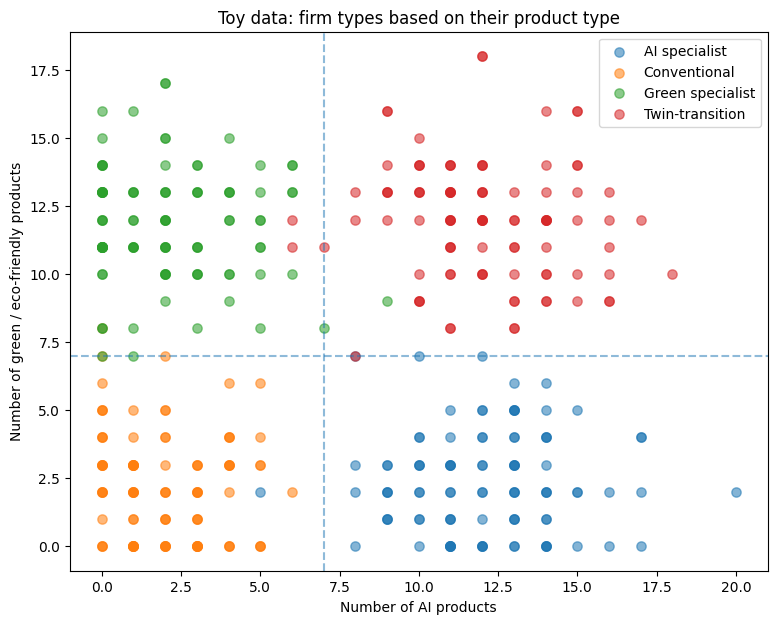

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

for label, group in firms.groupby("theoretical_type"):
    ax.scatter(
        group["ai_products"],
        group["green_products"],
        alpha=0.55,
        s=45,
        label=label
    )


# We use 7 as the threshold between "low" and "high" values.
# 7 is the midpoint between the two means used to generate the data: 2 and 12.
# (2 + 12) / 2 = 7

# Therefore:
# AI < 7  -> low AI
# AI >= 7 -> high AI
# Green < 7  -> low green
# Green >= 7 -> high green

# This creates the four theoretical categories:
# Conventional, AI specialist, Green specialist, and Twin-transition.
threshold = 7
ax.axvline(threshold, linestyle="--", alpha=0.5)
ax.axhline(threshold, linestyle="--", alpha=0.5)

ax.set_xlabel("Number of AI products")
ax.set_ylabel("Number of green / eco-friendly products")
ax.set_title("Toy data: firm types based on their product type")
ax.legend()

plt.show()

### What do the four quadrants mean?

For this toy example, we use **7 products as a simple theoretical threshold**:

- below 7 AI products = relatively low AI orientation
- 7 or more AI products = relatively high AI orientation
- below 7 green products = relatively low green orientation
- 7 or more green products = relatively high green orientation

These thresholds are part of the **toy theoretical classification**, not something AA estimates.

In [ ]:
def theoretical_quadrant(row):
    high_ai = row["ai_products"] >= 7
    high_green = row["green_products"] >= 7

    if not high_ai and not high_green:
        return "Conventional"
    elif high_ai and not high_green:
        return "AI specialist"
    elif not high_ai and high_green:
        return "Green specialist"
    else:
        return "Twin-transition"

firms["quadrant"] = firms.apply(theoretical_quadrant, axis=1)

pd.crosstab(firms["theoretical_type"], firms["quadrant"])

quadrant,AI specialist,Conventional,Green specialist,Twin-transition
theoretical_type,,,,
AI specialist,96,1,0,3
Conventional,0,97,3,0
Green specialist,0,0,98,2
Twin-transition,0,0,2,98


## 4. A quick comparison with k-means

Before AA, let's see what a conventional clustering approach does.

K-means searches for **centroids**: average-like points around which observations are grouped.

This is useful because it gives us a direct contrast:

- **K-means:** typical/central observations
- **AA:** extreme observations defining the data space

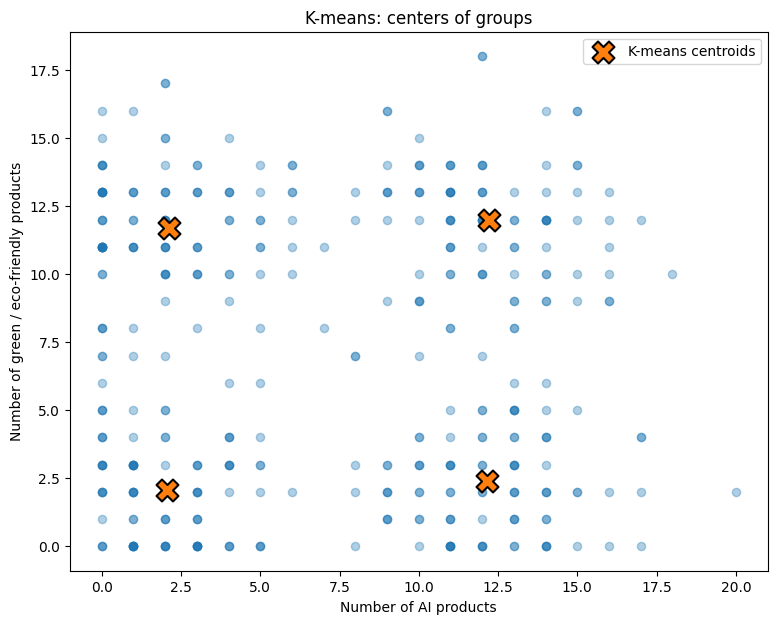

array([[ 2.13333333, 11.68571429],
       [12.14      ,  2.4       ],
       [12.20618557, 11.98969072],
       [ 2.05102041,  2.05102041]])

In [ ]:
# Select only the two variables that we want to use for clustering:
# the number of AI products and the number of green/eco-friendly products.
# .to_numpy() converts the pandas DataFrame into a NumPy array,
# which is the format expected by scikit-learn.
X_raw = firms[["ai_products", "green_products"]].to_numpy()


# Create a K-means clustering model.
kmeans = KMeans(

    # We ask K-means to divide the firms into 4 clusters.
    # This corresponds to the four theoretical types we created earlier.
    n_clusters=4,

    # Set the random seed so that the results are reproducible.
    random_state=42,

    # Run K-means 20 times with different initial centroid positions
    # and keep the best solution. This reduces the risk of getting
    # a poor solution because of an unlucky initialization.
    n_init=20
)


# Apply K-means to the firms and assign each firm to a cluster.
# fit_predict() first fits the K-means model to the data and then
# returns the cluster number assigned to each firm.
# The resulting cluster labels (0, 1, 2, 3) are stored in the dataset.
firms["kmeans_cluster"] = kmeans.fit_predict(X_raw)


# Extract the coordinates of the four K-means cluster centers.
# Each center represents the "average" firm in that cluster:
# [average AI products, average green products].
kmeans_centers = kmeans.cluster_centers_

fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(
    X_raw[:, 0],
    X_raw[:, 1],
    alpha=0.35,
    s=35
)

ax.scatter(
    kmeans_centers[:, 0],
    kmeans_centers[:, 1],
    marker="X",
    s=250,
    edgecolor="black",
    linewidth=1.5,
    label="K-means centroids"
)

ax.set_xlabel("Number of AI products")
ax.set_ylabel("Number of green / eco-friendly products")
ax.set_title("K-means: centers of groups")
ax.legend()

plt.show()

# Orange crosses show the K-means centroids:
# the typical (average) firm in each cluster.
# K-means therefore describes groups based on their averages.
kmeans_centers

## 5. Prepare the data for Archetypal Analysis

Although K-means gives us an idea of the average or typical firm in each group, what if we are interested in the extremes? For example, the top firms that combine many AI and green products, or firms that are doing poorly, with neither AI nor green products. This is where Archetypal Analysis (AA) becomes particularly useful.

**AA is sensitive to the scale of variables.**

Here the two variables have the same conceptual unit (number of products), but standardizing is still a useful practice when moving toward real firm-level datasets.

We will therefore use standardized values for the AA model.

**Important:** standardization does not change the ordering of firms on either dimension. It changes the scale used by the optimization.

In [ ]:
# Select the two variables that will be used in the analysis.
features = ["ai_products", "green_products"]

# Create a standardization object.
scaler = StandardScaler()

# Standardize both variables.
# For each variable:
#   z = (value - mean) / standard deviation

# After standardization:
#   mean = 0
#   standard deviation = 1
X = scaler.fit_transform(firms[features])
X[:5]

array([[-0.74648736, -1.36139774],
       [-0.93046453, -1.169042  ],
       [-0.74648736, -1.169042  ],
       [-0.37853302, -1.36139774],
       [-1.11444169, -0.97668626]])

## 6. Fit Archetypal Analysis with K archetypes

The Python `archetypes` package provides a scikit-learn-compatible `AA` estimator. The fitted model exposes:

- `archetypes_` — the extreme archetypal points
- `coefficients_` — the alpha coefficients describing each observation as a mixture of archetypes
- `arch_coefficients_` — the beta coefficients showing how archetypes themselves are constructed from observations
- `rss_` — reconstruction error

### How to interpret the scree plot

The RSS will almost always decline as K increases.

We are looking for a point where adding another archetype produces substantially less improvement — the **elbow**

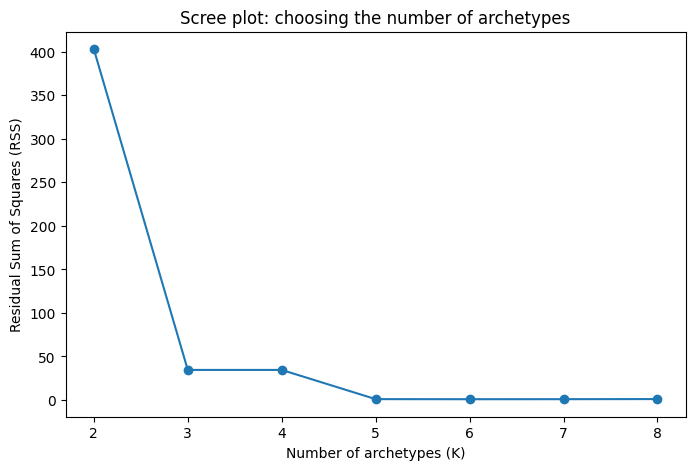

In [ ]:
# Although we know that our toy data were generated with four theoretical
# firm types, in real-world data the number of archetypes (K) is unknown.
# We therefore estimate models with different numbers of archetypes and
# use the RSS scree plot to help identify an appropriate value of K.

# Test different numbers of archetypes, from 2 to 8.
k_values = range(2, 9)

# Store the RSS (residual sum of squares) for each K.
rss_values = []

# Fit an AA model for each possible value of K.
for k in k_values:

    # Create the Archetypal Analysis model with K archetypes.
    aa = AA(
        n_archetypes=k,
        max_iter=1000,
        random_state=42
    )

    # Fit the model to the standardized data.
    aa.fit(X)

    # Store the RSS of the fitted model.
    rss_values.append(aa.rss_)

# Plot the RSS scree plot.
plt.figure(figsize=(8, 5))

# Plot the number of archetypes against the RSS.
plt.plot(k_values, rss_values, marker="o")

# Label the axes.
plt.xlabel("Number of archetypes (K)")
plt.ylabel("Residual Sum of Squares (RSS)")

# Add a title.
plt.title("Scree plot: choosing the number of archetypes")

# Show the possible K values clearly on the x-axis.
plt.xticks(list(k_values))

plt.show()

In [ ]:
# Based on the scree plot, K = 3 is the elbow:
# increasing K from 2 to 3 produces a very large reduction in RSS,
# while increasing K from 3 to 4 produces almost no improvement.

# Therefore, we choose 3 archetypes as a more parsimonious solution.
# Note that this is a data-driven choice: although our toy data were
# generated from four theoretical types, AA does not have to find four
# archetypes.

aa3 = AA(
    # Fit an Archetypal Analysis model with 3 archetypes.
    n_archetypes=3,

    # Allow the algorithm up to 1,000 iterations to converge.
    max_iter=1000,

    # Set the random seed so that the result is reproducible.
    random_state=42
)

# Fit the AA model to our standardized data.
aa3.fit(X)


# Number of iterations used by the algorithm before convergence.
print("Iterations:", aa3.n_iter_)

# Shape of the archetypes matrix:
# 3 archetypes × 2 variables (AI products and green products).
print("Archetypes shape:", aa3.archetypes_.shape)

# Shape of the alpha coefficient matrix:
# 400 firms × 3 archetypes.
# Each row shows how strongly a firm is represented by each archetype.
print("Alpha coefficients shape:", aa3.coefficients_.shape)

# Shape of the beta coefficient matrix:
# 3 archetypes × 400 firms.
# These coefficients show which firms contribute to the construction
# of each archetype.
print("Beta coefficients shape:", aa3.arch_coefficients_.shape)

Iterations: 78
Archetypes shape: (3, 2)
Alpha coefficients shape: (400, 3)
Beta coefficients shape: (3, 400)


## 7. Inspect the discovered archetypes

The model estimates archetypes in standardized units.

For interpretation, transform them back into the original **number-of-products** scale.

This makes the results much easier to explain to a substantive audience.

In [ ]:
# Extract the archetypes from the fitted AA model.
# The values are currently in standardized (z-score) units.
archetypes_scaled = aa3.archetypes_

# Convert the archetypes back to the original scale.
# This makes the results easier to interpret as actual numbers
# of AI and green products.
archetypes_original = scaler.inverse_transform(archetypes_scaled)

# Convert the archetypes into a pandas DataFrame.
# Each row represents one archetype and the columns represent
# the two variables used in the analysis.
archetypes_df = pd.DataFrame(
    archetypes_original,
    columns=["AI products", "Green products"]
)

# Create a label for each archetype.
# len(archetypes_df) automatically detects how many archetypes (K)
# were estimated, so this works for K = 3, 4, 5, etc.
archetypes_df.index = [
    f"Archetype {i+1}" for i in range(len(archetypes_df))
]

# Round the results to two decimal places to make the table easier to read.
archetypes_df.round(2)

,AI products,Green products
Archetype 1,19.60,3.58
Archetype 2,3.56,17.16
Archetype 3,0.00,0.00


### Interpretation

Do not immediately call Archetype 1 "AI specialist" simply because you expected it.

AA has **no knowledge of our theoretical labels**, and the numerical order of archetypes is arbitrary.

Instead, inspect the estimated values and assign substantive names **after** seeing the results.

This mirrors the logic of the paper: archetype names are descriptive and are developed from the attributes of the estimated archetypes.

## 8. Plot the AA archetypes in the original data space

The most intuitive visualization for this two-variable example is simply the original AI × green product space.

The **X markers are the archetypes**.

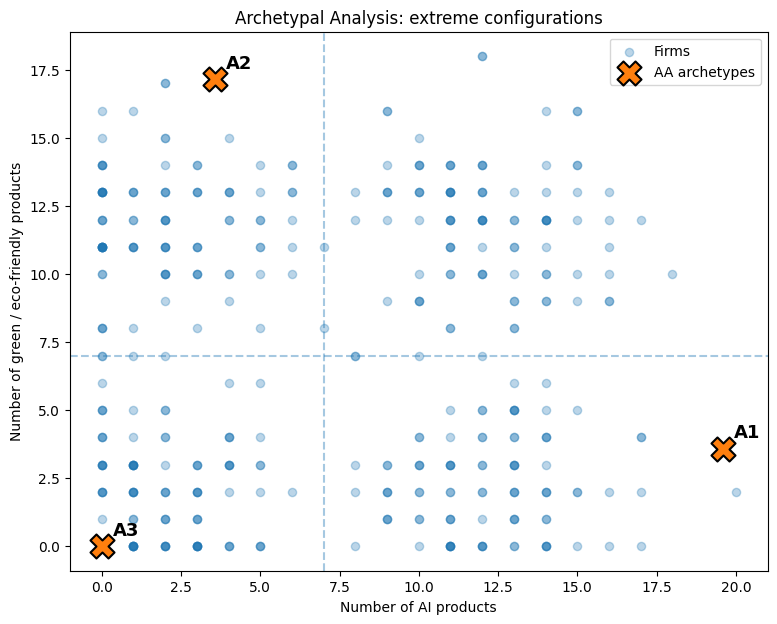

In [ ]:
# Create the figure and plotting area.
fig, ax = plt.subplots(figsize=(9, 7))

# Plot all firms using their actual AI and green product counts.
ax.scatter(
    firms["ai_products"],       # x-coordinate = number of AI products
    firms["green_products"],    # y-coordinate = number of green products
    alpha=0.30,                 # Make firms slightly transparent
    s=35,                       # Size of the firm points
    label="Firms"
)

# Plot the archetypes as large X symbols.
# IMPORTANT: we do NOT enter their coordinates manually.
# The coordinates come from the AA model.

# archetypes_original[:, 0] = AI-product coordinate of each archetype
# archetypes_original[:, 1] = Green-product coordinate of each archetype

# Because we selected K = 3, there will be 3 X symbols.
ax.scatter(
    archetypes_original[:, 0],
    archetypes_original[:, 1],
    marker="X",
    s=300,
    edgecolor="black",
    linewidth=1.5,
    label="AA archetypes"
)

# Add labels A1, A2, A3 to the archetypes.
# The loop automatically adjusts to the number of archetypes (K).
for i, (x, y) in enumerate(archetypes_original):

    # Place the label slightly above and to the right of each X.
    ax.annotate(
        f"A{i+1}",
        (x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=13,
        fontweight="bold"
    )

# Add the theoretical threshold of 7 AI products.
ax.axvline(7, linestyle="--", alpha=0.4)

# Add the theoretical threshold of 7 green products.
ax.axhline(7, linestyle="--", alpha=0.4)

# Label the x-axis.
ax.set_xlabel("Number of AI products")

# Label the y-axis.
ax.set_ylabel("Number of green / eco-friendly products")

# Add a title.
ax.set_title("Archetypal Analysis: extreme configurations")

# Show the legend.
ax.legend()

# Display the plot.
plt.show()

## 9. The alpha coefficients: firms as mixtures of archetypes

This is one of the most important parts of AA.

For each firm, AA estimates a vector of **alpha coefficients**.

For example:

```text
Firm A
A1 = 0.05
A2 = 0.90
A3 = 0.03
A4 = 0.02
```

The interpretation is:

> Firm A is very close to the pure type represented by Archetype 2.

Another firm might have:

```text
A1 = 0.40
A2 = 0.45
A3 = 0.05
A4 = 0.10
```

That firm is a **mixture** of two archetypal configurations.

This is why AA is different from assigning every observation to one mutually exclusive cluster.

In [ ]:
alpha = pd.DataFrame(
    aa4.coefficients_,
    columns=[f"A{i+1}" for i in range(4)]
)

alpha.insert(0, "firm", firms["firm"].values)

alpha.head()

,firm,A1,A2,A3,A4
0,Firm_001,0.000000,0.000000,0.852325,0.147675
1,Firm_002,0.001962,0.037540,0.865739,0.094759
2,Firm_003,0.001428,0.026880,0.823893,0.147799
3,Firm_004,0.000000,0.000000,0.753874,0.246126
4,Firm_005,0.010914,0.104027,0.855122,0.029937


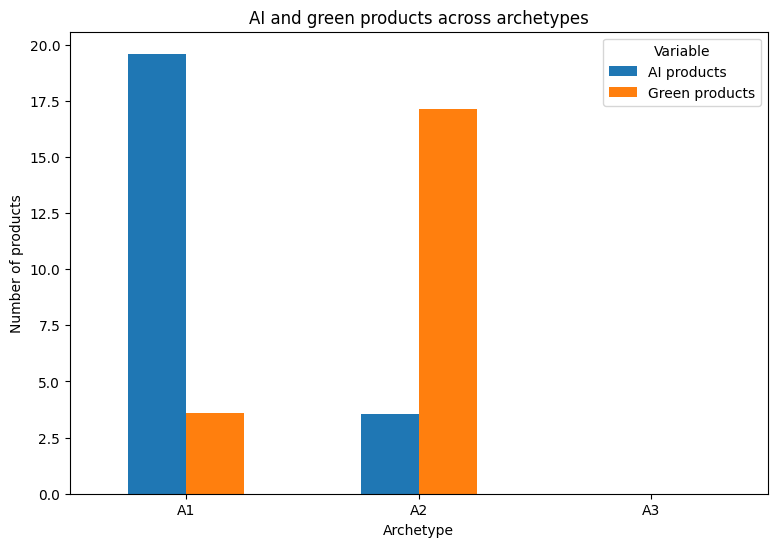

In [ ]:
# Create a DataFrame containing the values of each archetype.
# The values are on the original scale: number of AI and green products.
archetypes_plot = pd.DataFrame(
    archetypes_original,
    columns=["AI products", "Green products"]
)

# Give each row a dynamic archetype label: A1, A2, A3, ...
archetypes_plot.index = [
    f"A{i+1}" for i in range(len(archetypes_plot))
]

# Create a bar chart showing the value of each variable
# for each archetype.
ax = archetypes_plot.plot(
    kind="bar",
    figsize=(9, 6)
)

# Label the x-axis.
ax.set_xlabel("Archetype")

# Label the y-axis.
ax.set_ylabel("Number of products")

# Add a title.
ax.set_title("AI and green products across archetypes")

# Rotate the archetype labels so they are easy to read.
plt.xticks(rotation=0)

# Show the legend identifying the two variables.
ax.legend(title="Variable")

# Display the plot.
plt.show()

Every row should sum to approximately 1.

The coefficients are non-negative and sum to one because each firm is represented as a convex combination of archetypes.

In [ ]:
# Extract the alpha coefficients.
# Each row represents one firm, and each column represents one archetype.
alpha = aa3.coefficients_

# Check that all coefficients are non-negative.
print("Minimum alpha coefficient:", alpha.min())

# Calculate the sum of the alpha coefficients for each firm.
# Each firm's coefficients should sum to approximately 1.
alpha_sums = alpha.sum(axis=1)

# Show the first 10 firms and their coefficient sums.
print("\nSum of alpha coefficients for the first 10 firms:")
print(alpha_sums[:10])

# Check the minimum and maximum row sums.
print("\nMinimum row sum:", alpha_sums.min())
print("Maximum row sum:", alpha_sums.max())

# Check whether all firms' coefficients sum approximately to 1.
print(
    "\nDo all rows sum to approximately 1?",
    np.allclose(alpha_sums, 1)
)

# Put the alpha coefficients into a DataFrame for easier inspection.
alpha_df = pd.DataFrame(
    alpha,
    columns=[f"A{i+1}" for i in range(alpha.shape[1])]
)

# Add the row sum so we can verify the convex-combination property.
alpha_df["Sum"] = alpha_df.sum(axis=1)

# Display the first 10 firms.
alpha_df.head(10).round(3)

Minimum alpha coefficient: 0.0

Sum of alpha coefficients for the first 10 firms:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Minimum row sum: 0.9999999999999998
Maximum row sum: 1.0000000000000002

Do all rows sum to approximately 1? True


,A1,A2,A3,Sum
0,0.148,0.000,0.852,1.0
1,0.096,0.038,0.866,1.0
2,0.149,0.027,0.824,1.0
3,0.246,0.000,0.754,1.0
4,0.030,0.110,0.859,1.0
5,0.020,0.171,0.809,1.0
6,0.198,0.309,0.493,1.0
7,0.191,0.076,0.733,1.0
8,0.020,0.171,0.809,1.0
9,0.137,0.088,0.775,1.0


## 10. Assign a dominant archetype

In a classification exercise, we can assign each firm to the archetype with the largest alpha coefficient.

This creates a hard classification:

> dominant archetype = archetype with the largest mixture coefficient.

But remember: this is a **secondary classification step**. The underlying AA result is the continuous vector of alpha coefficients.

In [ ]:
# Extract the alpha coefficients from the fitted AA model.
# Each row = one firm.
alpha_values = aa3.coefficients_


# Find the archetype with the largest alpha coefficient for each firm.
# np.argmax(..., axis=1) finds the position of the largest value in each row.
#
# For example:
# [0.10, 0.80, 0.10] → Archetype 2
#
# +1 is added because Python starts counting at 0,
# while we want to label the archetypes A1, A2, A3.
firms["AA_archetype"] = (
    np.argmax(alpha_values, axis=1) + 1
)


# Calculate the largest alpha coefficient for each firm.
# This tells us how strongly the firm is associated with its
# dominant archetype.

# For example:
# [0.10, 0.80, 0.10] → AA strength = 0.80

# A value close to 1 means the firm is strongly represented by
# one archetype. A lower value means the firm is more mixed
# between several archetypes.
firms["AA_strength"] = (
    np.max(alpha_values, axis=1)
)


# Display the first 15 firms together with:
# - their AI products
# - their green products
# - their theoretical quadrant
# - the archetype they are most strongly associated with
# - the strength of that association
firms[
    [
        "firm",
        "ai_products",
        "green_products",
        "quadrant",
        "AA_archetype",
        "AA_strength"
    ]
].head(15)

,firm,ai_products,green_products,quadrant,AA_archetype,AA_strength
0,Firm_001,3,0,Conventional,3,0.852364
1,Firm_002,2,1,Conventional,3,0.866234
2,Firm_003,3,1,Conventional,3,0.824370
3,Firm_004,5,0,Conventional,3,0.753940
4,Firm_005,1,2,Conventional,3,0.859045
5,Firm_006,1,3,Conventional,3,0.809432
6,Firm_007,5,6,Conventional,3,0.492993
7,Firm_008,4,2,Conventional,3,0.732919
8,Firm_009,1,3,Conventional,3,0.809432
9,Firm_010,3,2,Conventional,3,0.775008


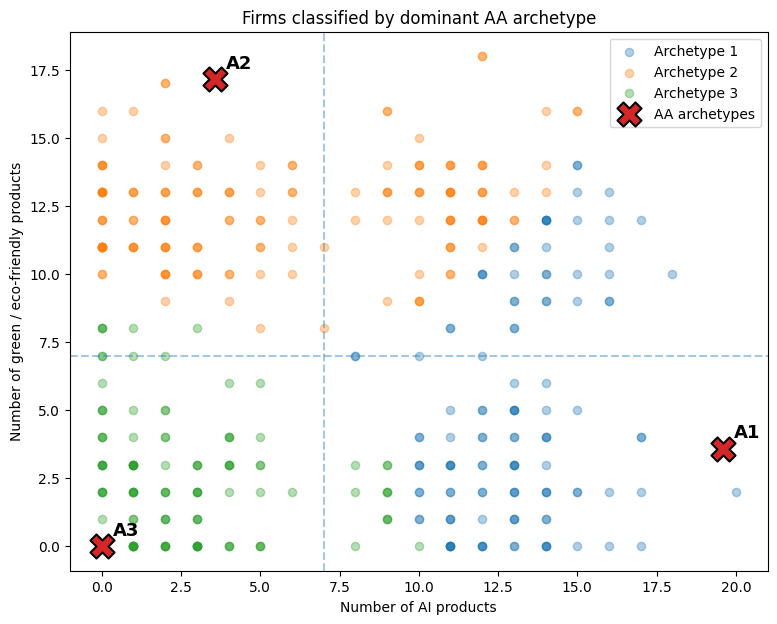

In [ ]:
# Create the figure.
fig, ax = plt.subplots(figsize=(9, 7))

# Plot firms, coloured according to their dominant AA archetype.
for archetype in sorted(firms["AA_archetype"].unique()):

    subset = firms[firms["AA_archetype"] == archetype]

    ax.scatter(
        subset["ai_products"],
        subset["green_products"],
        alpha=0.35,
        s=35,
        label=f"Archetype {archetype}"
    )

# Plot the AA archetypes as large X symbols.
# Their coordinates are calculated by Archetypal Analysis,
# not entered manually.
ax.scatter(
    archetypes_original[:, 0],   # AI-product coordinate
    archetypes_original[:, 1],   # Green-product coordinate
    marker="X",
    s=300,
    edgecolor="black",
    linewidth=1.5,
    label="AA archetypes"
)

# Label each archetype.
for i, (x, y) in enumerate(archetypes_original):

    ax.annotate(
        f"A{i+1}",
        (x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=13,
        fontweight="bold"
    )

# Add the theoretical thresholds used earlier.
ax.axvline(7, linestyle="--", alpha=0.4)
ax.axhline(7, linestyle="--", alpha=0.4)

# Label the axes.
ax.set_xlabel("Number of AI products")
ax.set_ylabel("Number of green / eco-friendly products")

# Add a title.
ax.set_title("Firms classified by dominant AA archetype")

# Show the legend.
ax.legend()

# Display the plot.
plt.show()

## 11. How "pure" are firms?

The maximum alpha coefficient provides a simple measure of archetypal purity.

- close to **1** → firm strongly resembles one archetype
- around **0.50** → firm lies between two archetypes
- lower values → firm is a more complex mixture

Let's inspect the distribution.

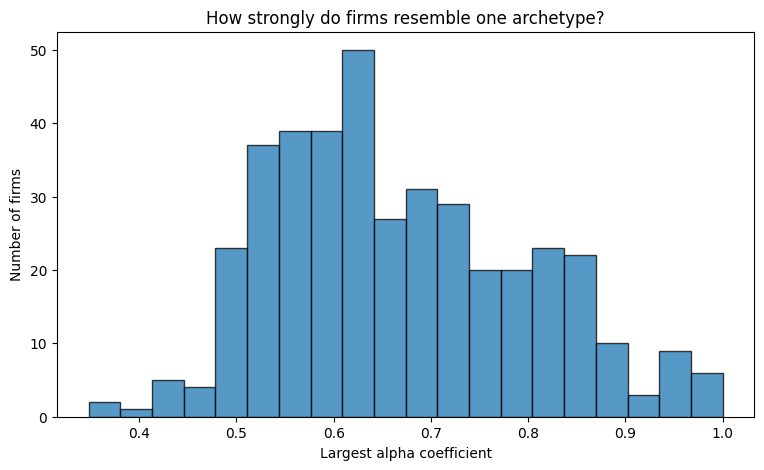

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    firms["AA_strength"],
    bins=20,
    edgecolor="black",
    alpha=0.75
)

ax.set_xlabel("Largest alpha coefficient")
ax.set_ylabel("Number of firms")
ax.set_title("How strongly do firms resemble one archetype?")

plt.show()

In [ ]:
# Set the minimum AA strength required to assign a firm to an archetype.
# Firms below this threshold have a mixed profile and are classified as "Other".
strength_threshold = 0.70

# Extract the alpha coefficients from the AA model.
# Each row = one firm; each column = one archetype.
alpha_values = aa3.coefficients_

# Find the strongest archetype for each firm.
dominant_archetype = np.argmax(alpha_values, axis=1) + 1

# Find how strongly each firm is represented by its dominant archetype.
aa_strength = np.max(alpha_values, axis=1)

# Store the dominant archetype and its strength in the dataset.
firms["AA_strength"] = aa_strength

# Assign firms to an archetype only when the dominant archetype
# has a strength of at least 70%.
# Otherwise, classify the firm as "Other".
firms["AA_type"] = np.where(
    firms["AA_strength"] >= strength_threshold,
    "Archetype " + dominant_archetype.astype(str),
    "Other"
)

# Display the number of firms in each category.
print(firms["AA_type"].value_counts())


AA_type
Other          257
Archetype 3     81
Archetype 2     46
Archetype 1     16
Name: count, dtype: int64


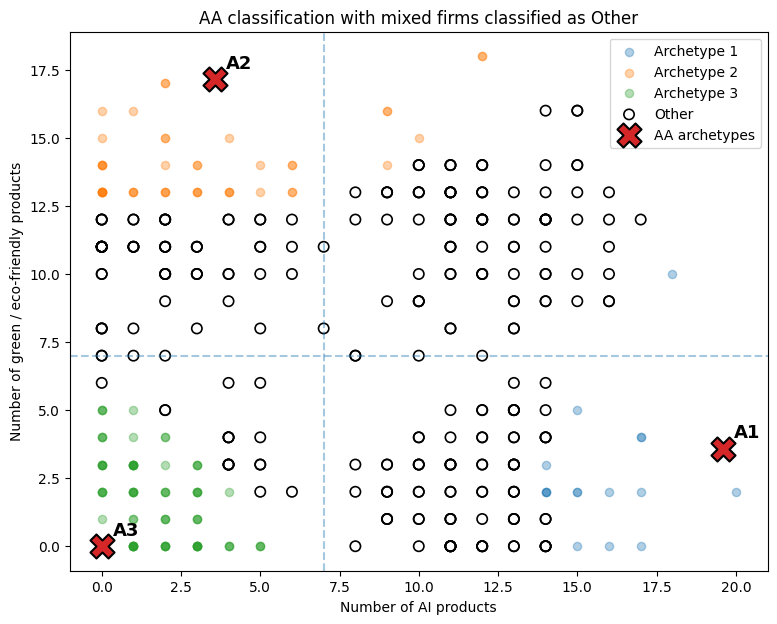

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

# Define the order for the legend.
plot_order = ["Archetype 1", "Archetype 2", "Archetype 3", "Other"]

# Plot the firms.
for category in plot_order:

    subset = firms[firms["AA_type"] == category]

    if category == "Other":
        # Other firms: no fill, only a black circular boundary.
        ax.scatter(
            subset["ai_products"],
            subset["green_products"],
            facecolors="none",
            edgecolors="black",
            s=55,
            linewidth=1.2,
            label=category
        )
    else:
        # Archetype-assigned firms.
        ax.scatter(
            subset["ai_products"],
            subset["green_products"],
            alpha=0.35,
            s=35,
            label=category
        )

# Plot the AA archetypes as large X symbols.
ax.scatter(
    archetypes_original[:, 0],
    archetypes_original[:, 1],
    marker="X",
    s=300,
    edgecolor="black",
    linewidth=1.5,
    label="AA archetypes"
)

# Label each archetype.
for i, (x, y) in enumerate(archetypes_original):
    ax.annotate(
        f"A{i+1}",
        (x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=13,
        fontweight="bold"
    )

# Add the theoretical thresholds.
ax.axvline(7, linestyle="--", alpha=0.4)
ax.axhline(7, linestyle="--", alpha=0.4)

# Labels and title.
ax.set_xlabel("Number of AI products")
ax.set_ylabel("Number of green / eco-friendly products")
ax.set_title("AA classification with mixed firms classified as Other")

# Legend: Archetype 1 → 2 → 3 → Other → AA archetypes.
ax.legend()

plt.show()

## 12. Recode AA's arbitrary numbers into substantive names

In [ ]:
# AA assigns arbitrary numbers to the archetypes.
# For example, "Archetype 1" does not inherently mean
# "AI specialist" or "Green specialist".
#
# We therefore recode the numerical labels based on the
# substantive characteristics of each archetype.

# First, inspect the archetype coordinates.
# Each row shows the number of AI and green products
# represented by that archetype.
archetypes_df.round(2)

,AI products,Green products
Archetype 1,19.60,3.58
Archetype 2,3.56,17.16
Archetype 3,0.00,0.00


In [ ]:
# Recode AA's arbitrary archetype numbers into substantive names.
# Based on the archetype coordinates:
#
# Archetype 1: high AI, low green  -> AI specialist
# Archetype 2: low AI, high green  -> Green specialist
# Archetype 3: low AI, low green   -> Conventional
#
# Firms with weak AA strength were previously classified as "Other".

archetype_names = {
    "Archetype 1": "AI specialist",
    "Archetype 2": "Green specialist",
    "Archetype 3": "Conventional"
}

# Apply the substantive names to the AA classification.
firms["AA_type_named"] = firms["AA_type"].map(archetype_names)

# Keep firms that did not meet the strength threshold as "Other".
firms["AA_type_named"] = firms["AA_type_named"].fillna("Other")

# Check the number of firms in each substantive category.
firms["AA_type_named"].value_counts()

,count
AA_type_named,
Other,257
Conventional,81
Green specialist,46
AI specialist,16


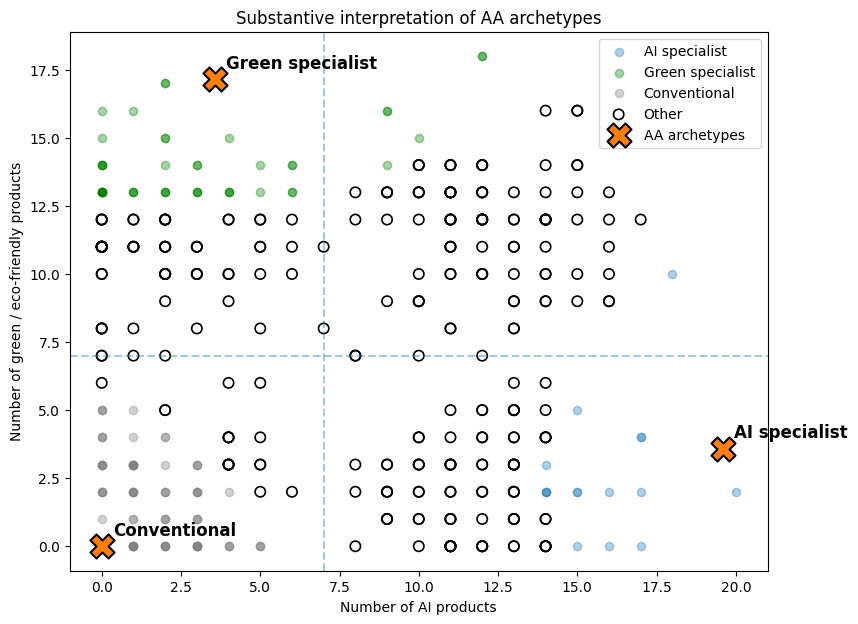

In [ ]:
# Define the desired order of categories.
plot_order = [
    "AI specialist",
    "Green specialist",
    "Conventional",
    "Other"
]

fig, ax = plt.subplots(figsize=(9, 7))

# Plot firms in the desired order.
for category in plot_order:

    subset = firms[firms["AA_type_named"] == category]

    if category == "Other":
        # Other firms: empty circles with a black boundary.
        ax.scatter(
            subset["ai_products"],
            subset["green_products"],
            facecolors="none",
            edgecolors="black",
            s=55,
            linewidth=1.2,
            label=category
        )
    elif category == "Green specialist":
        # Green specialists: green points.
        ax.scatter(
            subset["ai_products"],
            subset["green_products"],
            color="green",
            alpha=0.35,
            s=35,
            label=category
        )
    elif category == "Conventional":
        # Conventional firms: gray points.
        ax.scatter(
            subset["ai_products"],
            subset["green_products"],
            color="gray",
            alpha=0.35,
            s=35,
            label=category
        )
    else:
        # AI specialists: default colour.
        ax.scatter(
            subset["ai_products"],
            subset["green_products"],
            alpha=0.35,
            s=35,
            label=category
        )

# Plot the three AA archetypes as large X symbols.
ax.scatter(
    archetypes_original[:, 0],
    archetypes_original[:, 1],
    marker="X",
    s=300,
    edgecolor="black",
    linewidth=1.5,
    label="AA archetypes"
)

# Label the archetypes with their substantive names.
for i, (x, y) in enumerate(archetypes_original):

    name = archetype_names[f"Archetype {i+1}"]

    ax.annotate(
        name,
        (x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=12,
        fontweight="bold"
    )

# Add the theoretical thresholds.
ax.axvline(7, linestyle="--", alpha=0.4)
ax.axhline(7, linestyle="--", alpha=0.4)

# Labels and title.
ax.set_xlabel("Number of AI products")
ax.set_ylabel("Number of green / eco-friendly products")
ax.set_title("Substantive interpretation of AA archetypes")

# Legend order follows plot_order.
ax.legend()

plt.show()

## 13. The archetypal space

The two-dimensional AI × green plot is useful because we only have two variables.

With more variables, however, the original data space becomes difficult to visualize.

AA solves this by representing each firm through its **alpha coefficients**.

The package provides a simplex visualization for this purpose.

### How to read the simplex

Think of the corners as the pure archetypes:

- near one corner → strongly associated with one archetype
- along an edge → mixture of two archetypes
- inside the simplex → mixture of several archetypes

This is conceptually important because **AA is fundamentally a compositional representation**, not just a hard clustering algorithm.

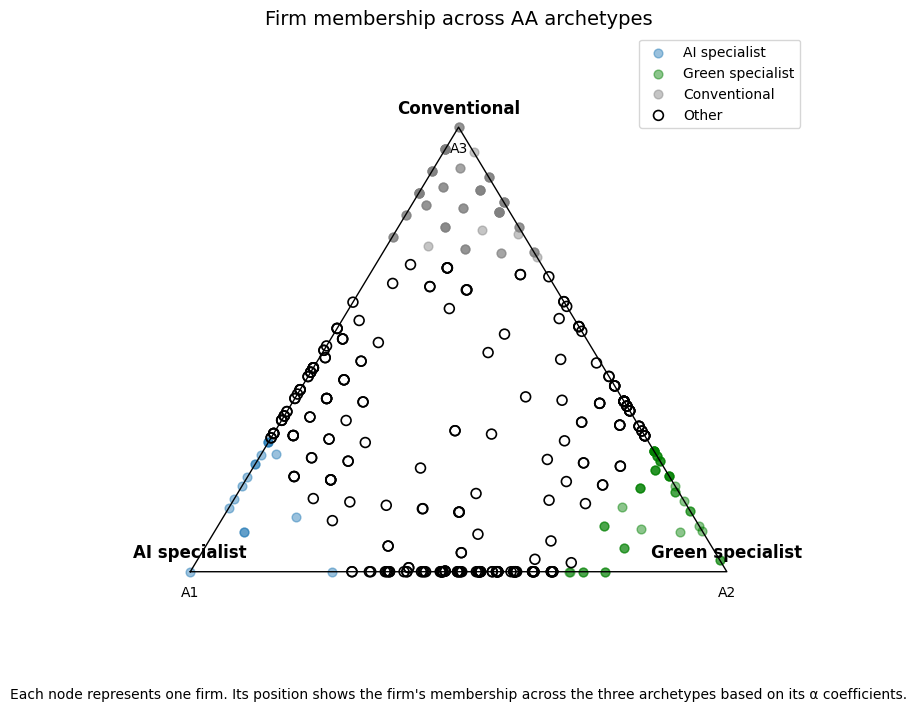

In [ ]:
# ---------------------------------------------------------
# Simplex plot: firm membership in the three archetypes
# ---------------------------------------------------------

# Extract the alpha coefficients.
# Each row = one firm
# Each column = membership in Archetype 1, 2, and 3.
alpha_values = aa3.coefficients_

# Define the coordinates of the three corners of the simplex.
# Each corner represents 100% membership in one archetype.
#
# A1 = (1, 0, 0)
# A2 = (0, 1, 0)
# A3 = (0, 0, 1)
#
# We convert these three membership combinations into
# 2-dimensional x/y coordinates for plotting.
A1 = np.array([0, 0])
A2 = np.array([1, 0])
A3 = np.array([0.5, np.sqrt(3) / 2])

# Calculate the position of every firm in the simplex.
# The position is a weighted combination of the three
# archetype coordinates, using the firm's alpha coefficients.
points = (
    alpha_values[:, [0]] * A1 +
    alpha_values[:, [1]] * A2 +
    alpha_values[:, [2]] * A3
)

# Create the figure.
fig, ax = plt.subplots(figsize=(9, 8))

# Define colours for the substantive categories.
category_colors = {
    "AI specialist": "tab:blue",
    "Green specialist": "green",
    "Conventional": "gray"
}

# Plot firms according to their AA classification.
for category in ["AI specialist", "Green specialist", "Conventional", "Other"]:

    # Select firms belonging to this category.
    mask = firms["AA_type_named"] == category

    if category == "Other":
        # Other firms are shown as empty circles with
        # a black boundary.
        ax.scatter(
            points[mask, 0],
            points[mask, 1],
            facecolors="none",
            edgecolors="black",
            s=50,
            linewidth=1.2,
            label="Other"
        )

    else:
        # Plot firms assigned to an archetype using the
        # same colours as in the previous figure.
        ax.scatter(
            points[mask, 0],
            points[mask, 1],
            color=category_colors[category],
            alpha=0.45,
            s=40,
            label=category
        )

# Draw the triangle connecting the three archetypes.
triangle = np.vstack([A1, A2, A3, A1])

ax.plot(
    triangle[:, 0],
    triangle[:, 1],
    color="black",
    linewidth=1
)

# Label the three corners with their substantive names.
corner_names = [
    archetype_names["Archetype 1"],
    archetype_names["Archetype 2"],
    archetype_names["Archetype 3"]
]

corner_positions = [A1, A2, A3]

for name, position in zip(corner_names, corner_positions):

    ax.annotate(
        name,
        position,
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

# Add the AA labels A1, A2, A3 underneath the substantive names.
for i, position in enumerate(corner_positions):

    ax.annotate(
        f"A{i+1}",
        position,
        xytext=(0, -18),
        textcoords="offset points",
        ha="center",
        fontsize=10
    )

# Add a caption explaining what each node represents.
ax.text(
    0.5,
    -0.08,
    "Each node represents one firm. Its position shows the firm's "
    "membership across the three archetypes based on its α coefficients.",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

# Remove the normal x and y axes because this is a simplex.
ax.set_xticks([])
ax.set_yticks([])

# Remove unnecessary borders.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

# Add the legend.
ax.legend()

# Add some space around the triangle.
ax.set_xlim(-0.15, 1.15)
ax.set_ylim(-0.15, 1.05)

# Add the title.
ax.set_title(
    "Firm membership across AA archetypes",
    fontsize=14
)

plt.show()

## 14. Stability across random initializations

Because AA is an optimization problem, it is good practice to check whether the solution is reasonably stable.

For our toy exercise, we can compare the RSS obtained from five different random seeds.

In [ ]:
stability = (
    rss_df
    .groupby("K")["RSS"]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)

stability

,mean,std,min,max
K,,,,
2,399.626,1.703,398.490,402.402
3,34.573,0.001,34.572,34.574
4,0.868,0.000,0.868,0.869
5,0.711,0.282,0.333,1.026
6,0.707,0.253,0.379,0.965
7,0.755,0.273,0.368,1.014
8,0.624,0.226,0.411,0.995


We select three archetypes because the scree plot indicates a substantial improvement in fit from K = 2 to K = 3, while adding a fourth archetype provides little additional benefit for the chosen representation. Moreover, the K = 3 solution is highly stable across random initializations, with RSS varying little across five runs (SD = 0.001).

For a real empirical application, you can go further and compare the **archetype positions and alpha coefficients**, not only RSS.

## 15. The beta coefficients: what observations define the archetypes?

AA has two sets of coefficients.

### Alpha coefficients

How much does each **firm resemble each archetype**?

### Beta coefficients

How is each **archetype constructed from the original firms**?

This second perspective is particularly useful when you want to identify the actual firms that sit at the extreme boundaries of the data.

In [ ]:
beta = aa3.arch_coefficients_

print("Beta matrix shape:", beta.shape)
print("Rows = archetypes; columns = firms")

Beta matrix shape: (3, 400)
Rows = archetypes; columns = firms


In [ ]:
# Extract beta coefficients: rows = archetypes, columns = firms
beta = aa3.arch_coefficients_

# Report the 5 firms with the highest beta for each archetype
for i in range(beta.shape[0]):

    # Get beta values for the current archetype
    beta_values = beta[i, :]

    # Find the 5 firms with the largest beta coefficients
    top_firms = np.argsort(beta_values)[-5:][::-1]

    # Create a small beta matrix in the same format as before
    beta_top5 = pd.DataFrame(
        beta[:, top_firms],
        index=[f"A{j+1}" for j in range(beta.shape[0])],
        columns=[firms.iloc[j]["firm"] for j in top_firms]
    )

    # Report the selected firms and their beta coefficients
    print(
        f"\nBeta coefficients for the 5 firms contributing most to "
        f"Archetype {i+1} ({archetype_names[f'Archetype {i+1}']}):"
    )
    print(beta_top5.round(3))


Beta coefficients for the 5 firms contributing most to Archetype 1 (AI specialist):
    Firm_110  Firm_355  Firm_128  Firm_129  Firm_130
A1     0.802     0.198       0.0       0.0       0.0
A2     0.000     0.000       0.0       0.0       0.0
A3     0.000     0.000       0.0       0.0       0.0

Beta coefficients for the 5 firms contributing most to Archetype 2 (Green specialist):
    Firm_262  Firm_284  Firm_356  Firm_363  Firm_128
A1     0.000     0.000     0.000     0.000       0.0
A2     0.422     0.422     0.078     0.078       0.0
A3     0.000     0.000     0.000     0.000       0.0

Beta coefficients for the 5 firms contributing most to Archetype 3 (Conventional):
    Firm_027  Firm_024  Firm_064  Firm_127  Firm_128
A1     0.000     0.000     0.000       0.0       0.0
A2     0.000     0.000     0.000       0.0       0.0
A3     0.333     0.333     0.333       0.0       0.0


This is an important empirical advantage of AA.

You can move from:

> "What is the archetype?"

to:

> "Which real firms are contributing most strongly to the archetype?"

That can be especially useful for case-study selection or qualitative follow-up.

## 16. A useful distinction: theoretical quadrants vs. empirical archetypes

This toy example illustrates an important methodological point.

### Theoretical classification

You define:

- low vs high AI
- low vs high green

and therefore obtain four theoretically defined quadrants.

### Archetypal classification

You do **not** impose the quadrants.

Instead, AA estimates extreme configurations from the observed data.

The two approaches can then be compared.

This gives us a useful empirical question:

> **Do the theoretically defined categories correspond to the empirical extreme configurations actually observed among firms?**

That is a stronger use of AA than simply using it as another clustering algorithm.

## 17. Final takeaway

The central lesson is not simply how to run:

```python
AA(n_archetypes=K)
```

The important methodological logic is:

1. **Start with a theoretically meaningful multivariate space.**
2. **Identify potential extreme configurations.**
3. **Use AA to estimate archetypes from the data rather than imposing them.**
4. **Inspect the estimated archetype characteristics.**
5. **Represent every firm through alpha coefficients.**
6. **Use dominant archetype labels only as a convenient summary.**
7. **Check alternative K values and stability.**
8. **Interpret the results substantively and theoretically.**

For the AI–green product example, the substantive question becomes:

> **Are firms organized around distinct extreme configurations of AI and green product portfolios, and to what extent do individual firms represent mixtures of these configurations?**

That is the archetypal-analysis perspective.

## Now it is your turn

So far, we have used simulated data to understand Archetypal Analysis (AA). Now it is your turn to apply the methods to real-world data.

Use City data (shared by Hamid: https://sds-aau.github.io/SDS-master/M1/data/cities.csv) and apply Archetypal Analysis (AA).

Your task
- What does each cluster/archetype represent?
- What are the "pure" city types revealed by AA?
- Is K-means or AA more useful for understanding these city types? Why?


## References and further reading

**Abbasiharofteh, M.** *From Average to Extremes: Application of Archetypal Analysis in Economic Geography.* see: https://www.sciencedirect.com/science/article/pii/S2949694225000070

**Cutler & Breiman (1994).** Archetypal Analysis. *Technometrics*, 36(4), 338–347.

**Eugster & Leisch (2009).** From Spider-Man to Hero: Archetypal Analysis in R. *Journal of Statistical Software*, 30(8), 1–23.

For the Python implementation used here, see the `archetypes` library.